## Задание

Скачайте материалы к занятию.

Проанализируйте 6 временных рядов из папки Series и сделайте их стационарными:

  - monthly-sales-of-company-x-jan-6.csv
  - monthly-boston-armed-robberies-j.csv
  - international-airline-passengers.csv
  - mean-monthly-air-temperature-deg.csv
  - weekly-closings-of-the-dowjones-.csv
  - daily-total-female-births-in-cal.csv
  
Пришлите решение в виде ссылки на GitHub с ноутбуком.

In [1]:
# ========== ИМПОРТ БИБЛИОТЕК ==========

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

# scipy — для преобразования Бокса-Кокса (стабилизация дисперсии)
from scipy.stats import boxcox

# adfuller — расширенный тест Дики-Фуллера для проверки стационарности
from statsmodels.tsa.stattools import adfuller

# acf — автокорреляционная функция для анализа сезонности
from statsmodels.tsa.stattools import acf

# plot_acf — график автокорреляции (коррелограмма)
from statsmodels.graphics.tsaplots import plot_acf

from google.colab import drive

%matplotlib inline

In [2]:
# ========== ПОДКЛЮЧАЕМ GOOGLE DRIVE ==========

drive.mount("/content/drive/")

Mounted at /content/drive/


In [4]:
# ========== ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ==========

def set_datetime_index(df, date_col, date_format=None, freq=None):
  """
  Преобразует колонку с датами в DatetimeIndex.
    Параметры:
      df - таблица с данными
      date_col - название колонки с датами
      date_format - формат даты
      freq - частота
  Возвращает:
      pandas.DataFrame - таблица с DatetimeIndex
  """
  df_copy = df.copy()

  if date_format == '%Y-W%W': # Если дата в формате "Год-Неделя"
    df_copy[date_col] = pd.to_datetime(df_copy[date_col].astype(str) + '-1', format='%Y-W%W-%w') # '-1' (понедельник) для корректного преобразования в дату
  elif date_format:
    df_copy[date_col] = pd.to_datetime(df_copy[date_col], format=date_format)
  else:
      df_copy[date_col] = pd.to_datetime(df_copy[date_col])

  df_copy.set_index(date_col, inplace=True)

  # Уставнавливаем частоту данных(необходимо для определения сезонности)
  if freq:
    try:
      df_copy.index.freq = freq
    except ValueError as e:
      # Если частота не совпадает, пробуем определить автоматически
      infered_freq = pd.infer_freq(df_copy.index)
      if infered_freq:
        print(f"Частота {freq} не совпадает с данными, устанавливаем '{infered_freq}'")
        df_copy.index.freq = infered_freq
      else:
        print(f"Не удалось установить частоту '{freq}', оставляем без частоты")

  return df_copy


def get_season_period(series):
  """
  Определяет период сезонности по частоте индекса.
  Необходимо для сезонного дифференцирования
  """
  if hasattr(series.index, 'freq') and series.index.freq is not None:
    freq = str(series.index.freq)
    if 'MS' in freq or 'M' in freq:
      return 12
    elif 'W' in freq:
      return 52
    elif 'D' in freq:
      return 7
    elif 'Q' in freq:
      return 4
  print("Не удалось определить период по частоте, возьмем 12")
  return 12


def get_info(df, name='Ряд'):
  """
  Выводит информацию о временном ряде.
  """
  print('='*50)
  print(f"{name}")
  print('='*50)
  print(df.head())
  print(f"Индекс: {df.index[:3]}")
  print(f"Частота: {df.index.freq}")

In [5]:
# ========== ЗАГРУЗКА ДАННЫХ ==========

sales_of_company_x = pd.read_csv("/content/drive/MyDrive/Netology/ВременныеРяды/Series/monthly-sales-of-company-x-jan-6.csv")
sales_of_company_x = set_datetime_index(
    sales_of_company_x,
    'Month',
    date_format='%Y-%m',
    freq='MS'
)

robberies_in_boston = pd.read_csv("/content/drive/MyDrive/Netology/ВременныеРяды/Series/monthly-boston-armed-robberies-j.csv")
robberies_in_boston = set_datetime_index(
    robberies_in_boston,
    'Month',
    date_format='%Y-%m',
    freq='MS'
)

airlines_passengers = pd.read_csv("/content/drive/MyDrive/Netology/ВременныеРяды/Series/international-airline-passengers.csv")
airlines_passengers = set_datetime_index(
    airlines_passengers,
    'Month',
    date_format='%Y-%m',
    freq='MS'
)

mean_monthly_temp = pd.read_csv("/content/drive/MyDrive/Netology/ВременныеРяды/Series/mean-monthly-air-temperature-deg.csv")
mean_monthly_temp = set_datetime_index(
    mean_monthly_temp,
    'Month',
    date_format='%Y-%m',
    freq='MS'
)

dowjones_closing = pd.read_csv("/content/drive/MyDrive/Netology/ВременныеРяды/Series/weekly-closings-of-the-dowjones-.csv")
dowjones_closing = set_datetime_index(
    dowjones_closing,
    'Week',
    date_format='%Y-W%W',
    freq='W'
)

female_births = pd.read_csv("/content/drive/MyDrive/Netology/ВременныеРяды/Series/daily-total-female-births-in-cal.csv")
female_births = set_datetime_index(
    female_births,
    'Date',
    date_format='%Y-%m-%d',
    freq='D'
)

dataset = {"Продажи": sales_of_company_x,
          "Ограбления": robberies_in_boston,
          "Пассажиры": airlines_passengers,
          "Температура": mean_monthly_temp,
          "Dow Jones": dowjones_closing,
          "Рождаемость": female_births}

for name, df in dataset.items():
  get_info(df, name)

print("\nsales_of_company_x:", sales_of_company_x.shape)
print("robberies_in_boston:", robberies_in_boston.shape)
print("airlines_passengers:", airlines_passengers.shape)
print("mean_monthly_temp:", mean_monthly_temp.shape)
print("dowjones_closing:", dowjones_closing.shape)
print("female_births:", female_births.shape)

Не удалось установить частоту 'W', оставляем без частоты
Продажи
            Count
Month            
1965-01-01    154
1965-02-01     96
1965-03-01     73
1965-04-01     49
1965-05-01     36
Индекс: DatetimeIndex(['1965-01-01', '1965-02-01', '1965-03-01'], dtype='datetime64[ns]', name='Month', freq='MS')
Частота: <MonthBegin>
Ограбления
            Count
Month            
1966-01-01     41
1966-02-01     39
1966-03-01     50
1966-04-01     40
1966-05-01     43
Индекс: DatetimeIndex(['1966-01-01', '1966-02-01', '1966-03-01'], dtype='datetime64[ns]', name='Month', freq='MS')
Частота: <MonthBegin>
Пассажиры
            Count
Month            
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
Индекс: DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01'], dtype='datetime64[ns]', name='Month', freq='MS')
Частота: <MonthBegin>
Температура
             Deg
Month           
1920-01-01  40.6
1920-02-01  40.8
1920-03-01  44.4
1920-04-01  46.7
1920-05-01 

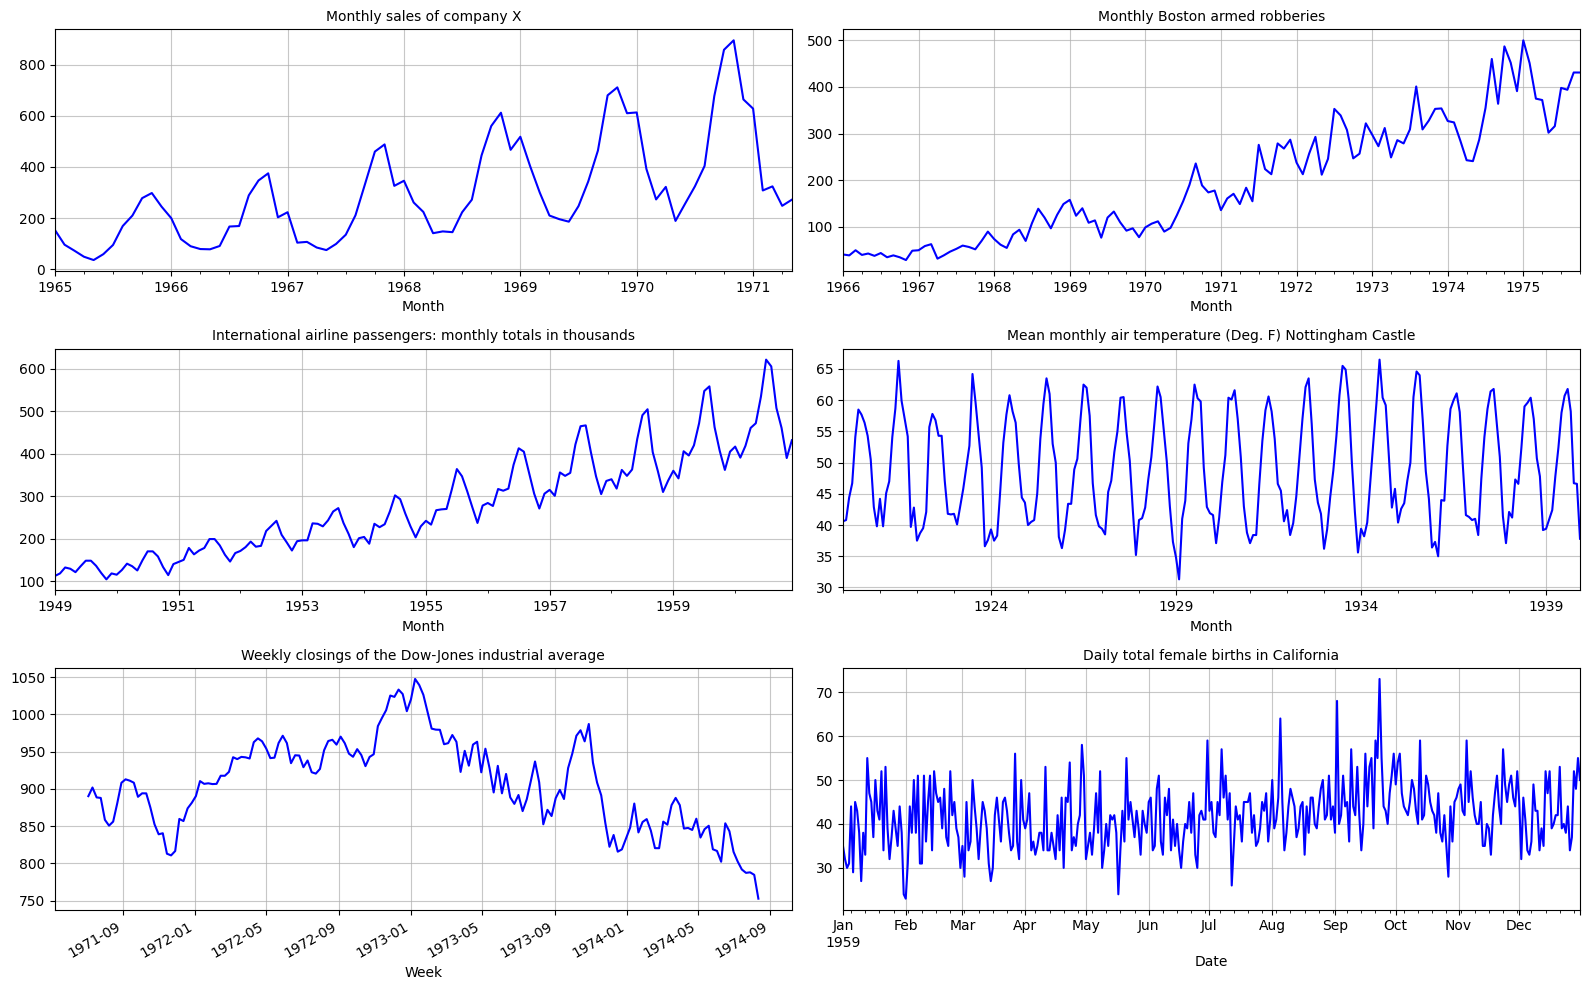

In [6]:
# ========== ВИЗУАЛИЗАЦИЯ ==========

all_series = {
    "Monthly sales of company X": sales_of_company_x["Count"],
    "Monthly Boston armed robberies": robberies_in_boston["Count"],
    "International airline passengers: monthly totals in thousands": airlines_passengers["Count"],
    "Mean monthly air temperature (Deg. F) Nottingham Castle": mean_monthly_temp["Deg"],
    "Weekly closings of the Dow-Jones industrial average": dowjones_closing["Close"],
    "Daily total female births in California": female_births["Count"]
}

plt.figure(figsize=(16, 10))
for i, (name, data) in enumerate(all_series.items()):
  plt.subplot(3, 2, i+1)
  data.plot(color='blue')
  plt.title(name, fontsize=10)
  plt.grid(True, alpha=0.7)

plt.tight_layout()
plt.show()

### ВЫВОД

На основе первичного визуального анализа временных рядов, можно сделать следующие выводы:
  1. Только ряд авиапассажиров демонстрирует растущую дисперсию, что требует применения преобразования Box-Cox для стабилизации размаха колебаний. Остальные ряды имеют стабильную дисперсию.
  2. Тренд присутствует у 4 рядов (продажи, ограбления, авиапассажиры, Dow Jones). Для их приведения к стационарному виду необходимо применить первое дифференцирование (diff(1)). Ряды температуры и рождаемости уже стационарны по тренду и не требуют данного преобразования.
  3. 5 рядов имеют явную сезонность (продажи, ограбления, авиапассажиры, температура, рождаемость).
  Для Dow Jones сезонность не очевидна на графике, требуется анализ ACF для подтверждения или опровержения.
  Для рядов с подтвержденной сезонностью необходимо применить сезонное дифференцирование с соответствующим периодом.


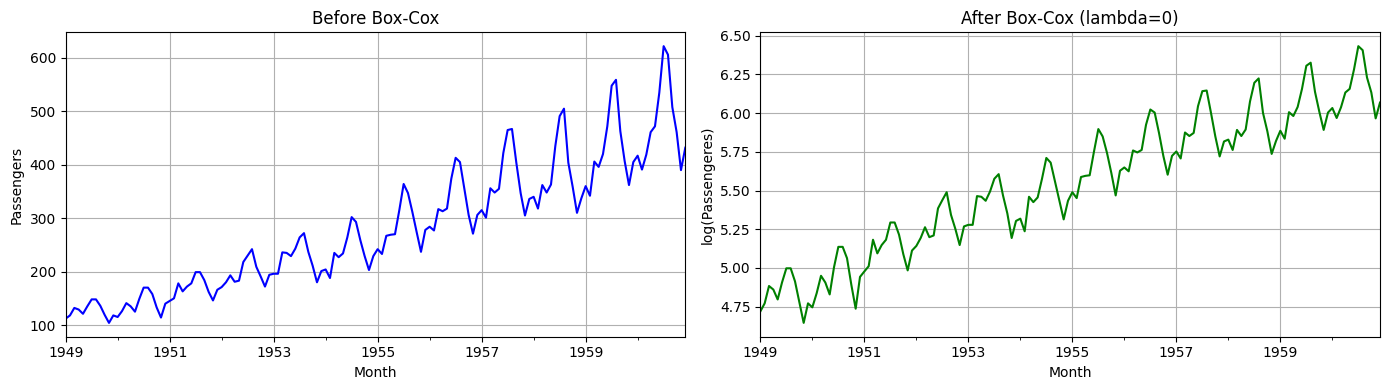

In [7]:
# ========== НОРМАЛИЗАЦИЯ ДИСПЕРСИИ ==========

# boxcox(x, 0) — логарифмическое преобразование (lambda=0)
airline_norm = pd.Series(
    boxcox(all_series['International airline passengers: monthly totals in thousands'], 0),
    index=all_series['International airline passengers: monthly totals in thousands'].index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

all_series['International airline passengers: monthly totals in thousands'].plot(ax=axes[0], color='blue')
axes[0].set_title('Before Box-Cox')
axes[0].set_ylabel('Passengers')
axes[0].grid(True)

airline_norm.plot(ax=axes[1], color='green')
axes[1].set_title('After Box-Cox (lambda=0)')
axes[1].set_ylabel('log(Passengeres)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
# ========== ПРОВЕРКА НА ТРЕНД(тест Дики-Фуллера) ==========

def test_stationarity(timeseries):
  """    Проверяет стационарность ряда с помощью расширенного теста Дики-Фуллера (ADF)"""
  print('Results of Dickey-Fuller Test:')
  dftest = adfuller(timeseries.dropna(), autolag='AIC') # autolag='AIC' — автоматический выбор лага
  dfoutput = pd.Series(
      dftest[0:4],
      index=['Test Statistic',              # значение тестовой статистики
             'p-value',                     # вероятность ошибки при отвержении H0
             '#Lags Used',                  # количество использованных лагов
             'Number of Observations Used'] # количество наблюдений после удаления пропусков
  )
  for key, value in dftest[4].items():
    dfoutput[f'Critical Value ({key})'] = value # критические значения для 1%, 5%, 10%
  print(dfoutput)

  if dftest[1] < 0.05:
    print(f'Ряд стационарен(тренда нет): (p-value: {dftest[1]:.6f} < 0.05)')
    return False
  else:
    print(f'Ряд не стационарен(тренд есть): (p-value: {dftest[1]:.6f} >= 0.05)')
    return True


# Проверяем наличие/отсутствие тренда на всех временных рядах
trend_info = {}
for name, series in all_series.items():
  print(f"\n{'='*50}")
  print(f'Ряд - {name}')
  print(f'='*50)

  # Для ряда аваиапасажиров используем нормализованный ряд
  if name == "International airline passengers: monthly totals in thousands":
    data = airline_norm
  else:
    data = series

  has_trend = test_stationarity(data)
  trend_info[name] = {"has_trend": has_trend,
                      "data": data}

print(f"\n{'='*50}")
print("Результаты ADF-теста")
print('='*50)
for name, info in trend_info.items():
  status = "Есть тренд" if info["has_trend"] else "Тренда нет"
  print(f"{name:<40} {status}")


Ряд - Monthly sales of company X
Results of Dickey-Fuller Test:
Test Statistic                  0.654715
p-value                         0.988889
#Lags Used                     12.000000
Number of Observations Used    64.000000
Critical Value (1%)            -3.536928
Critical Value (5%)            -2.907887
Critical Value (10%)           -2.591493
dtype: float64
Ряд не стационарен(тренд есть): (p-value: 0.988889 >= 0.05)

Ряд - Monthly Boston armed robberies
Results of Dickey-Fuller Test:
Test Statistic                   1.001102
p-value                          0.994278
#Lags Used                      11.000000
Number of Observations Used    106.000000
Critical Value (1%)             -3.493602
Critical Value (5%)             -2.889217
Critical Value (10%)            -2.581533
dtype: float64
Ряд не стационарен(тренд есть): (p-value: 0.994278 >= 0.05)

Ряд - International airline passengers: monthly totals in thousands
Results of Dickey-Fuller Test:
Test Statistic                  -1.

In [11]:
# ========== УДАЛЕНИЕ ТРЕНДА ==========

# Словарь для хранения преобразованных рядов
transformed_series = {}

for name, info in trend_info.items():
  print(f"\n{'='*50}")
  print(f"Ряд: {name}")
  print('='*50)

  if info['has_trend']:
    print("Тренд есть - применяем diff(1)")
    transformed = info['data'].diff().dropna()
    transformed_series[name] = transformed

    # Проверяем
    test_stationarity(transformed)

  else:
    print("Тренда нет - оставляем без изменений")
    transformed_series[name] = info['data']

print()
for name, series in transformed_series.items():
  p_value = adfuller(series.dropna(), autolag='AIC')[1]
  status = "Тренда нет" if p_value < 0.05 else "Есть тренд"
  print(f"{name:<40} {status} (p_value: {p_value:.6f})")


Ряд: Monthly sales of company X
Тренд есть - применяем diff(1)
Results of Dickey-Fuller Test:
Test Statistic                 -2.587970
p-value                         0.095509
#Lags Used                     12.000000
Number of Observations Used    63.000000
Critical Value (1%)            -3.538695
Critical Value (5%)            -2.908645
Critical Value (10%)           -2.591897
dtype: float64
Ряд не стационарен(тренд есть): (p-value: 0.095509 >= 0.05)

Ряд: Monthly Boston armed robberies
Тренд есть - применяем diff(1)
Results of Dickey-Fuller Test:
Test Statistic                -7.428564e+00
p-value                        6.450795e-11
#Lags Used                     1.000000e+01
Number of Observations Used    1.060000e+02
Critical Value (1%)           -3.493602e+00
Critical Value (5%)           -2.889217e+00
Critical Value (10%)          -2.581533e+00
dtype: float64
Ряд стационарен(тренда нет): (p-value: 0.000000 < 0.05)

Ряд: International airline passengers: monthly totals in thousan

## ВЫВОД

После применения diff(1):

  - Тренд удален у рядов: Ограбления, Dow Jones.

  - Тренд остался у рядов: Продажи, Пассажиры.
    Тренд остался потому что первая разность удаляет только линейный тренд. Но если в ряду есть сезонность, то после diff(1) она остается, и тест Дики-Фуллера все еще показывает нестационарность.

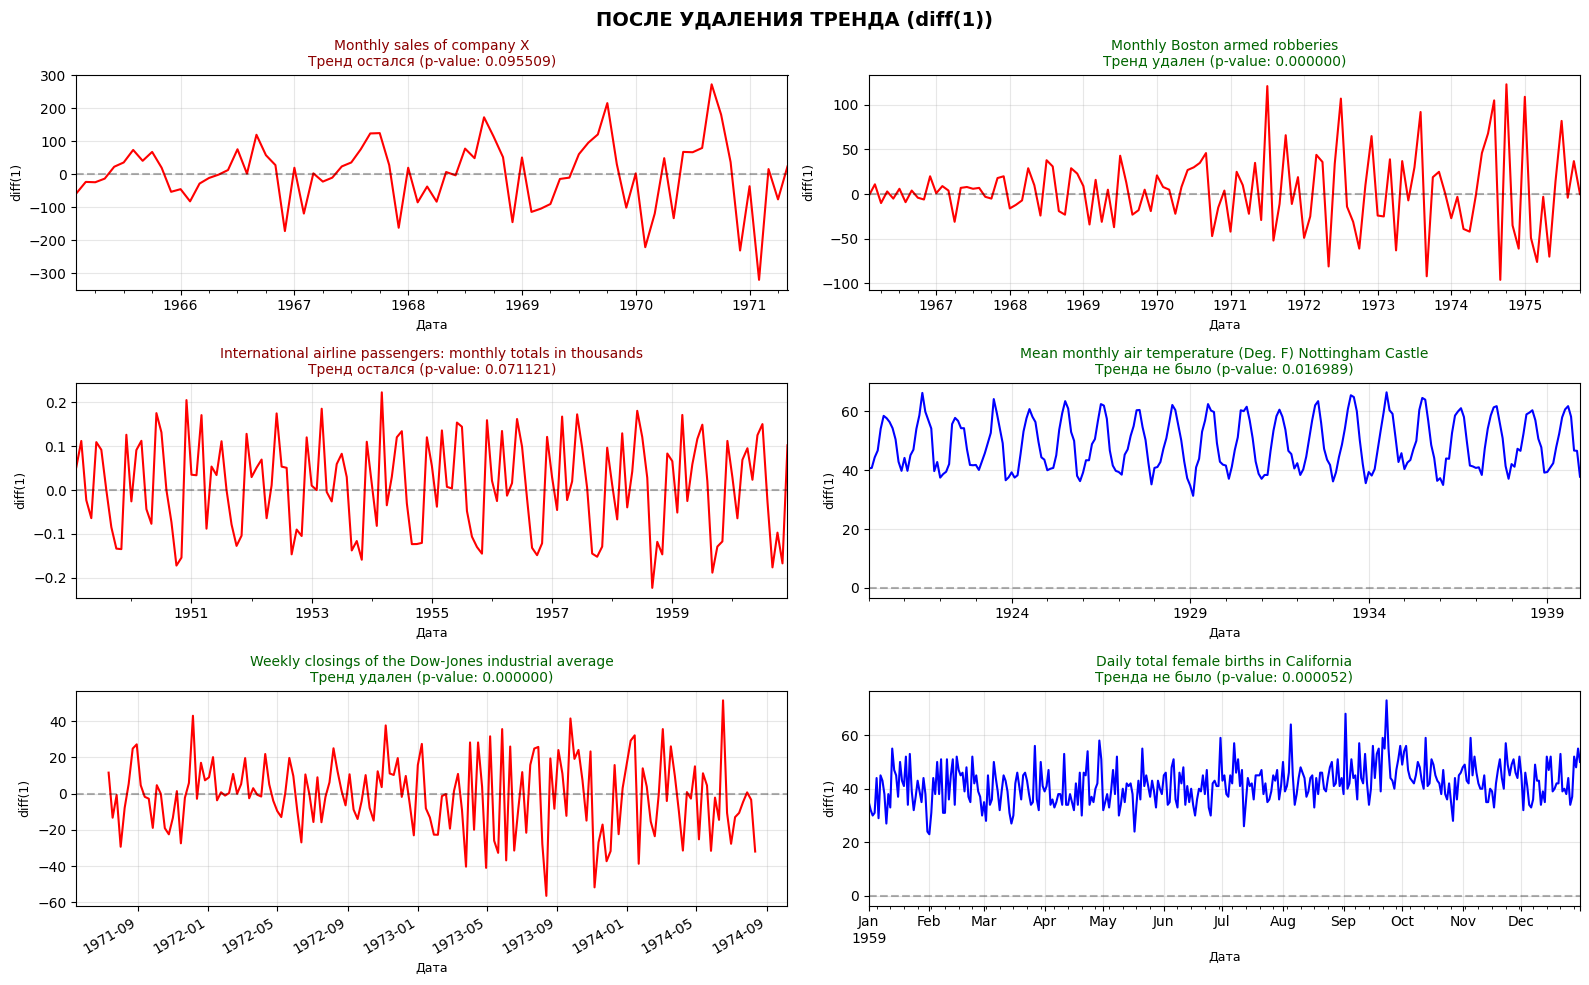

In [12]:
# ========== ВИЗУАЛИЗАЦИЯ ПОСЛЕ УДАЛЕНИЯ ТРЕНДА ==========

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes_flat = axes.flatten()

for i, (name, series) in enumerate(transformed_series.items()):
    ax = axes_flat[i]

    color = 'red' if trend_info[name]["has_trend"] else 'blue'
    series.plot(ax=ax, color=color, linewidth=1.5)

    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

    p_value = adfuller(series.dropna())[1]
    is_stationary = p_value < 0.05

    if trend_info[name]["has_trend"]:
        trend_status = "Тренд удален" if is_stationary else "Тренд остался"
    else:
        trend_status = "Тренда не было"

    ax.set_title(
        f"{name}\n{trend_status} (p-value: {p_value:.6f})",
        fontsize=10,
        color='darkgreen' if is_stationary else 'darkred'
    )
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Дата', fontsize=9)
    ax.set_ylabel('diff(1)', fontsize=9)

plt.suptitle('ПОСЛЕ УДАЛЕНИЯ ТРЕНДА (diff(1))', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ВЫВОД

  - Тренд был удален (Ограбления, Dow Jones)

  - Ряды с оставшейся сезонностью (Продажи, Пассажиры) все еще имеют циклическую структуру. Это значит, что для них нужен следующий шаг — удаление сезонности

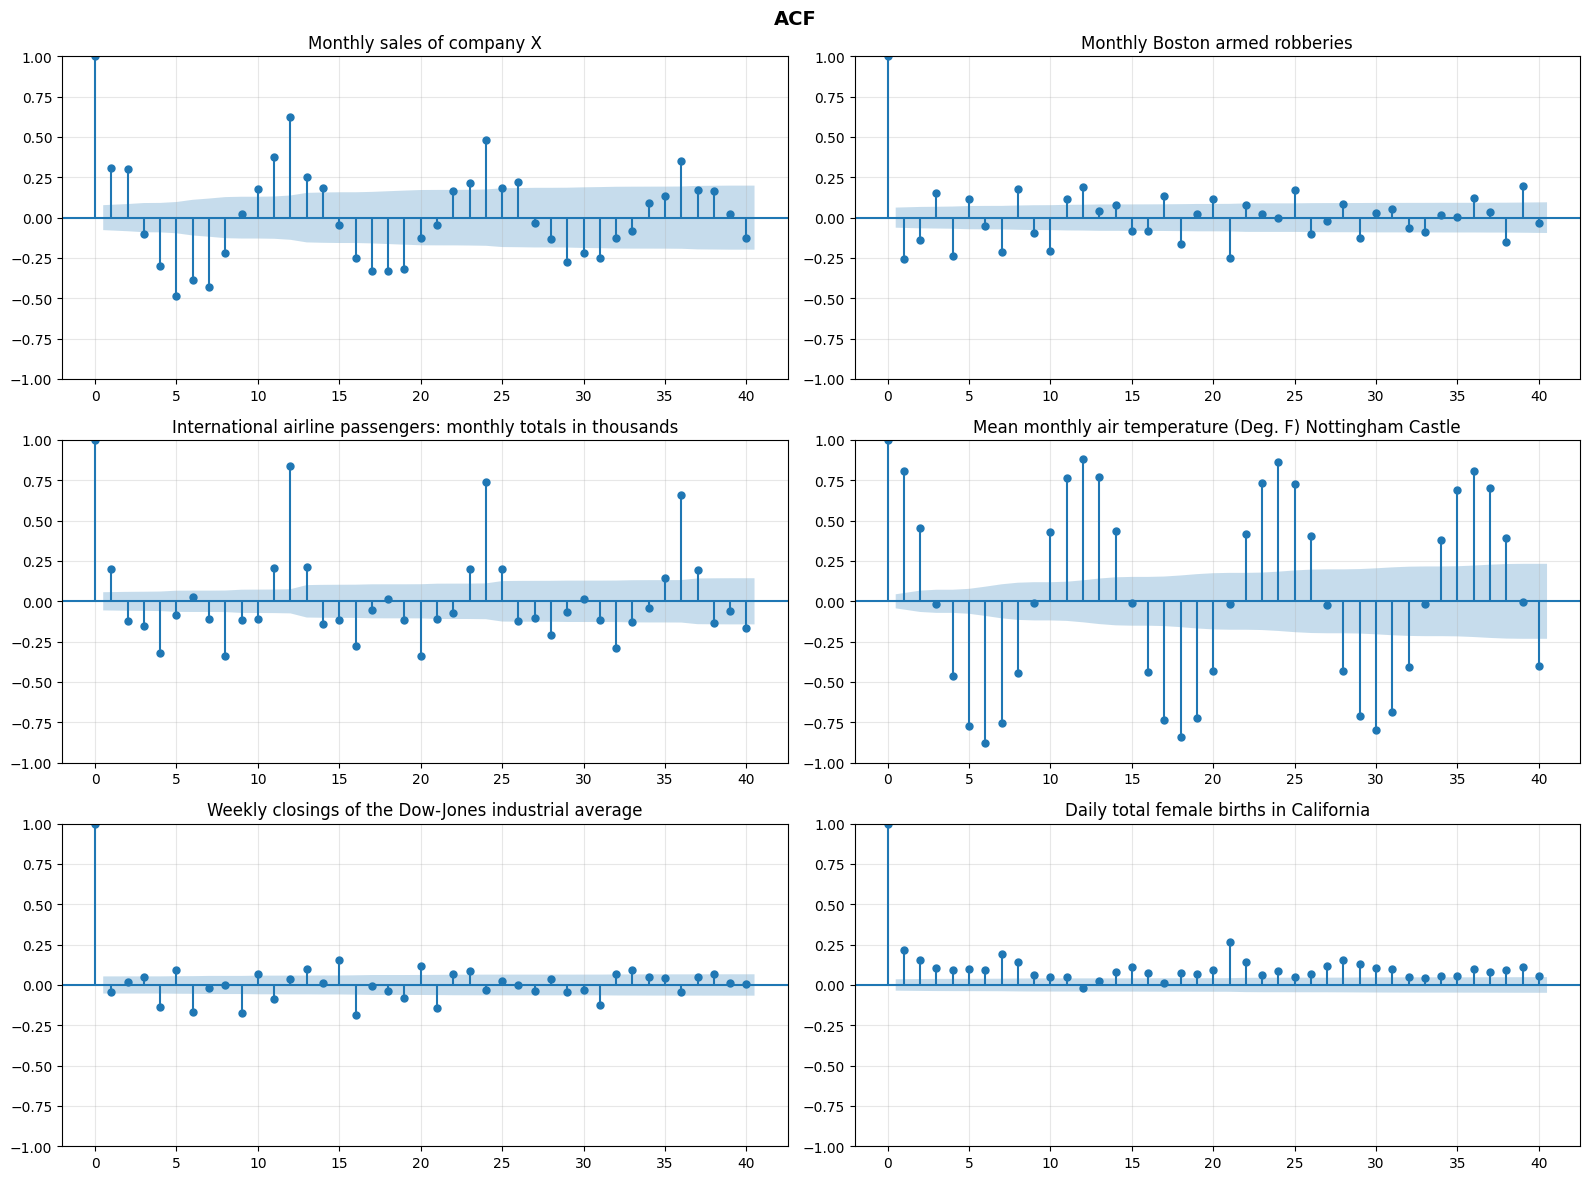

In [ ]:
# ========== АНАЛИЗ СЕЗОННОСТИ(ACF) ==========

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (name, series) in enumerate(transformed_series.items()):
  ax = axes_flat[i]
  plot_acf(series.dropna(), ax=ax, lags=40, alpha=0.5)
  ax.set_title(f"{name}")
  ax.grid(True, alpha=0.3)

plt.suptitle("ACF", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ВЫВОД

  - У рядов Продажи, Ограбления, Пассажиры, Температура есть значимые пики на лагах 12, 24, 36. Сезонность есть - период 12

  - У ряда Рождаемость есть значимые пики на лагах 7, 14, 21. Сезонность есть - период 7

  - У ряда Dow Jones значимых пиков нет. Сезонность отсутствует

In [13]:
# ========== УДАЛЕНИЕ СЕЗОННОСТИ ==========

stat_series = {}

for name, series in transformed_series.items():
  period = get_season_period(series)

  if period and period > 1:
    print(f"\n{name}: период сезонности = {period}")

    # Применяем сезонное дифференцирование
    stat_series[name] = series.diff(period).dropna()

    # После сезонного дифференцирования проверяем стационарность    p_value = adfuller(stat_series[name].dropna())[1]
    p_value = adfuller(stat_series[name].dropna())[1]

    # Если ряд все еще не стационарен, применяем дополнительное diff(1)
    # Это нужно, если после удаления сезонности остался тренд или другие зависимости
    if p_value >= 0.05:
        print(f" - Ряд не стационарен (p-value: {p_value:.6f})")
        print(f" - Применяем дополнительное diff(1)")
        stat_series[name] = stat_series[name].diff().dropna()

    test_stationarity(stat_series[name])

  else:
      print(f"{name}: сезонность не обнаружена")
      stat_series[name] = series


Monthly sales of company X: период сезонности = 12
 - Ряд не стационарен (p-value: 0.086332)
 - Применяем дополнительное diff(1)
Results of Dickey-Fuller Test:
Test Statistic                -5.911303e+00
p-value                        2.634936e-07
#Lags Used                     1.000000e+01
Number of Observations Used    5.200000e+01
Critical Value (1%)           -3.562879e+00
Critical Value (5%)           -2.918973e+00
Critical Value (10%)          -2.597393e+00
dtype: float64
Ряд стационарен(тренда нет): (p-value: 0.000000 < 0.05)

Monthly Boston armed robberies: период сезонности = 12
Results of Dickey-Fuller Test:
Test Statistic                 -4.615965
p-value                         0.000121
#Lags Used                     12.000000
Number of Observations Used    92.000000
Critical Value (1%)            -3.503515
Critical Value (5%)            -2.893508
Critical Value (10%)           -2.583824
dtype: float64
Ряд стационарен(тренда нет): (p-value: 0.000121 < 0.05)

International 

## ВЫВОД

  - Для всех рядов с сезонностью (период 12 или 7) применено сезонное дифференцирование

  - Для ряда Продажи потребовалось дополнительное diff(1), чтобы окончательно убрать все зависимости.

  В итоге все ряды стали стационарными (p-value < 0.05).

Не удалось определить период по частоте, возьмем 12


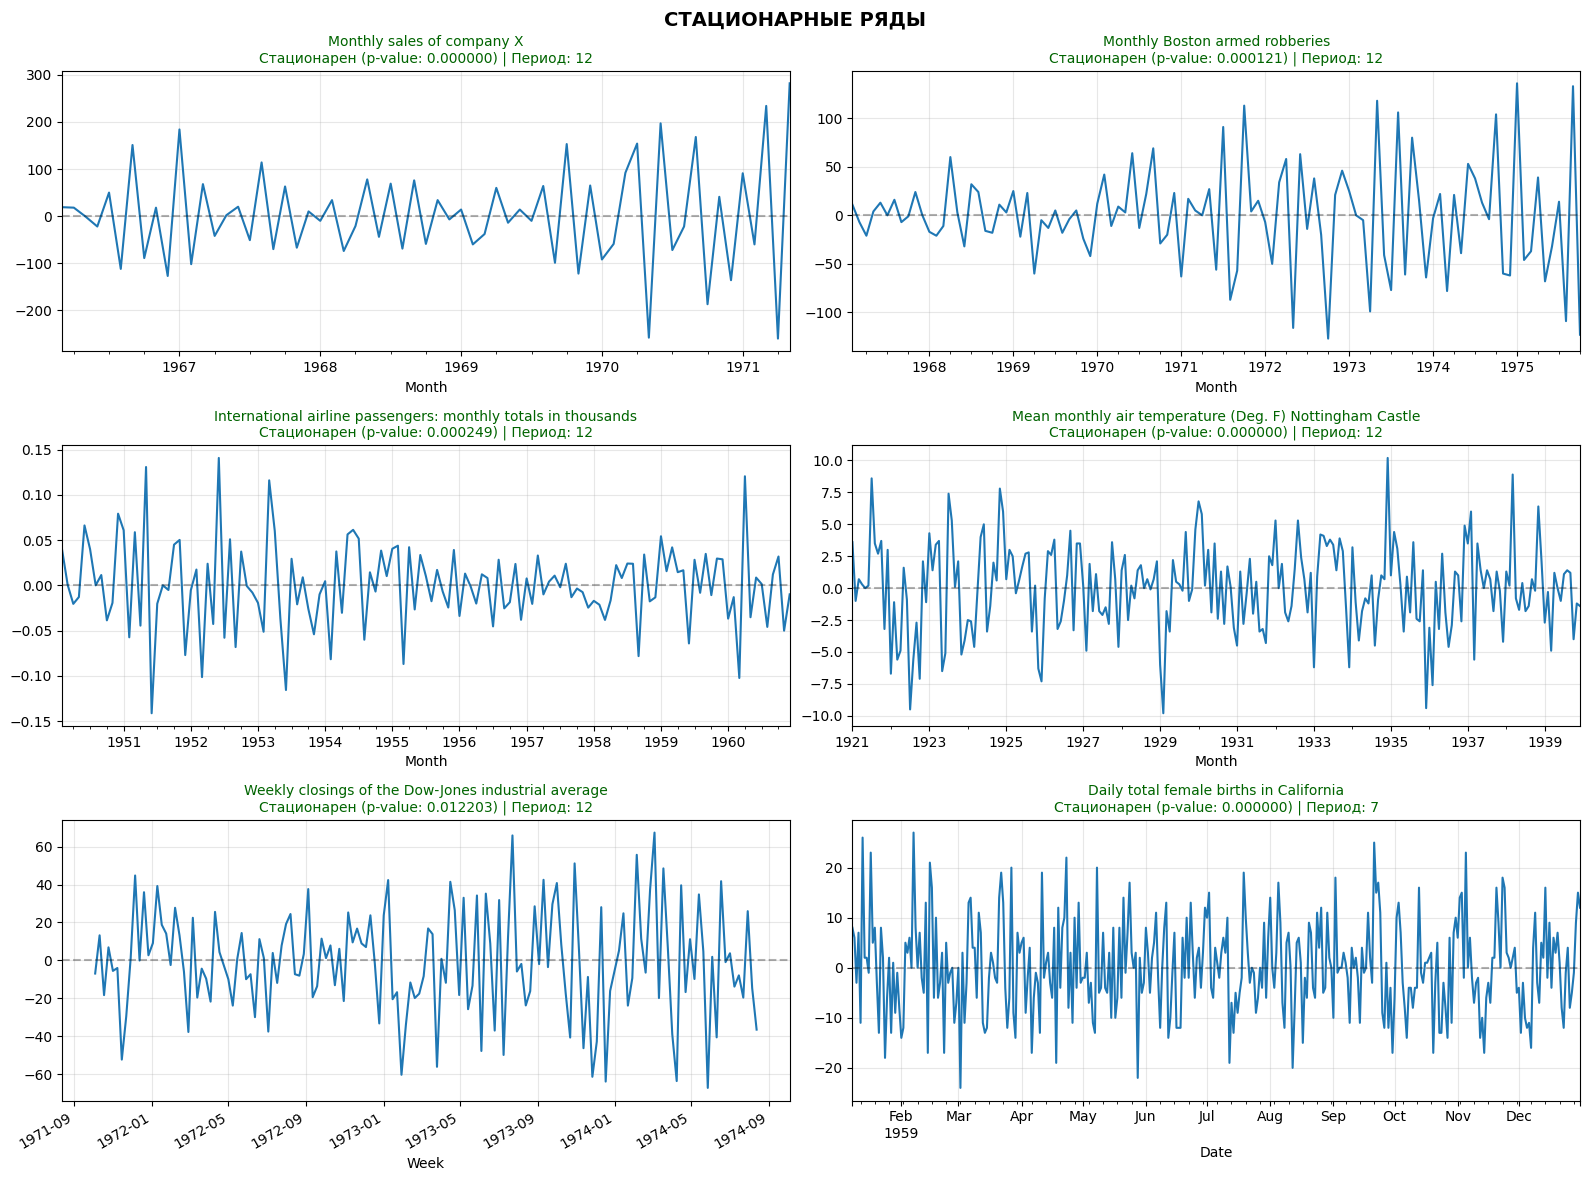

In [14]:
# ========== ВИЗУАЛИЗАЦИЯ ==========

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes_flat = axes.flatten()

for i, (name, series) in enumerate(stat_series.items()):
    ax = axes_flat[i]

    series.plot(ax=ax, linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='--', alpha=0.3)

    p_value = adfuller(series.dropna())[1]
    is_stationary = p_value < 0.05
    period = get_season_period(series)

    status = "Стационарен" if is_stationary else "Не стационарен"
    ax.set_title(
        f"{name}\n{status} (p-value: {p_value:.6f}) | Период: {period if period else '-'}",
        fontsize=10,
        color='darkgreen' if is_stationary else 'darkred'
    )
    ax.grid(True, alpha=0.3)

plt.suptitle('СТАЦИОНАРНЫЕ РЯДЫ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## ВЫВОД

Все шесть рядов приведены к стационарному виду.

  - Визуально, графики колеблются вокруг нуля, нет трендов и сезонных паттернов

  - Статистически — p-value < 0.05 для всех рядов по тесту Дики-Фуллера

##